# This project is to understand how to build a neural network and not a perfect model to work. Just for the basic understanding

In [2]:
import numpy as np
import pandas as pd


In [3]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
# everything looks fine so let's check about any duplicate rows

In [6]:
df.duplicated().sum()

0

In [7]:
# no duplicate rows


In [8]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [9]:
# let's drop the unnecessary columns from the dataset


In [10]:
df.drop(columns= ['RowNumber', 'CustomerId', 'Surname'], inplace = True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
# using get_dummies to convert the categorical columns - Gender and Geography 


In [12]:
df = pd.get_dummies(df,columns=['Geography', 'Gender'], drop_first= True, dtype=int)

In [13]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [14]:
# train test split the dataset

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x = df.drop(columns=['Exited'])
y = df['Exited']

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state= 42)

In [18]:
x_train.shape

(8000, 11)

In [19]:
# scale the data

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()



In [21]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [24]:
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

In [25]:
# let's create the model

In [39]:
model = Sequential()

model.add(Dense(8, activation='relu', input_dim = 11)) # hidden layer - 8 perceptron
model.add(Dense(1, activation= 'sigmoid')) # output layer

/Users/krishprakash/Desktop/ML/env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
# now we need to compile the model

In [41]:
model.compile(loss = 'binary_crossentropy', optimizer="Adam", metrics=['accuracy'])

In [42]:
history = model.fit(x_train_scaled, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 425us/step - accuracy: 0.8012 - loss: 0.5048 - val_accuracy: 0.7987 - val_loss: 0.4747
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 245us/step - accuracy: 0.7981 - loss: 0.4672 - val_accuracy: 0.7987 - val_loss: 0.4501
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 255us/step - accuracy: 0.7921 - loss: 0.4661 - val_accuracy: 0.7987 - val_loss: 0.4371
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 246us/step - accuracy: 0.7924 - loss: 0.4422 - val_accuracy: 0.8050 - val_loss: 0.4285
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 251us/step - accuracy: 0.8012 - loss: 0.4379 - val_accuracy: 0.8194 - val_loss: 0.4212
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 247us/step - accuracy: 0.8132 - loss: 0.4273 - val_accuracy: 0.8225 - val_loss: 0.4148
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 243us/step - accuracy: 0.8250 - loss: 0.4115 - val_accuracy: 0.8275 - val_loss: 0.4090
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 252us/step - accuracy: 0.8260 - loss: 0

In [43]:
# now let's get the weights and biases of the model

In [44]:
model.layers[0].get_weights()

[array([[-8.52269530e-02,  1.26160844e-03,  3.05090725e-01,
          4.47585955e-02,  3.66372988e-02, -3.15000601e-02,
         -6.57815039e-02, -4.04781133e-01],
        [-3.23396713e-01,  3.96677673e-01, -4.41128761e-01,
         -9.16728616e-01, -8.11293244e-01, -4.26637083e-01,
         -9.20559168e-02, -3.73895019e-01],
        [-3.65595110e-02,  3.72017547e-02,  7.76352510e-02,
         -1.78146183e-01, -6.65020943e-02,  1.18246704e-01,
         -1.19954951e-01,  2.34534308e-01],
        [-4.63509351e-01, -6.08023927e-02,  8.92393664e-02,
         -1.86830461e-01,  1.37536619e-02, -1.13967575e-01,
          4.70270008e-01,  1.80203438e-01],
        [-2.15545607e+00, -5.21855429e-02, -4.46547687e-01,
         -9.98374261e-03,  3.49570028e-02, -1.86058506e-02,
          2.02700996e+00, -4.32653129e-01],
        [-5.37737571e-02,  1.07231580e-01,  1.36150956e-01,
         -1.70296267e-01,  1.46561479e-02, -8.54040682e-02,
         -1.09315708e-01,  9.69966501e-02],
        [-3.7791

In [45]:
# now let's predict
y_log = model.predict(x_test_scaled)
y_log

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step


array([[0.03249633],
       [0.02278436],
       [0.14750451],
       ...,
       [0.72565454],
       [0.08549255],
       [0.26998147]], dtype=float32)

In [46]:
# the result is not in 0/1 format because the activation function used was sigmoid. now we need to convert this into 
# 0/1 format. and for this we need threshold value which can't be calculated without plotting AUC-ROC. so we just assume - 
# that anything greater than 0.5 is 1 and less than that is 0.

In [47]:
y_pred = np.where(y_log>0.5, 1,0)
y_pred

array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]])

In [48]:
# let's calculate the accuracy
from sklearn.metrics import accuracy_score


In [49]:
accuracy_score(y_test, y_pred)

0.8615

now to increase accuracy - activation function can be set to 'ReLu', nodes in hidden layer can be increased(eg - from 3 to 5)
or number of epochs can be increased(eg - from 10 to 100/1000), number of hidden layers can be increased(eg - here only 1 hidden layer).
But increasing number of hidden layers can sometimes lead to overfitting, so experiment and then see which is the best. 

In [50]:
# let's create a graph of the history

In [51]:
import matplotlib.pyplot as plt
%matplotlib inline

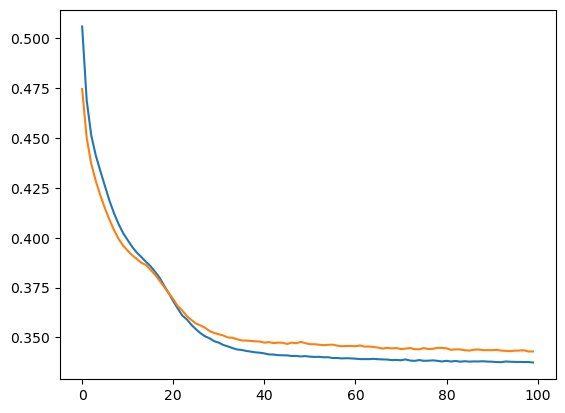

In [54]:
plt.plot(history.history['loss'] )
plt.plot(history.history['val_loss'])

plt.show()

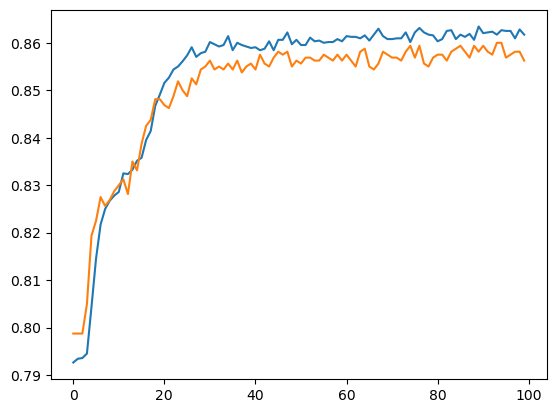

In [55]:
plt.plot(history.history['accuracy'] )
plt.plot(history.history['val_accuracy'])

plt.show()